In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.drop("Loan_ID", axis=1, inplace=True)

In [4]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [6]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])
df = pd.get_dummies(df, columns=["Property_Area"], dtype=int)
df = pd.get_dummies(df, columns=["Dependents"], dtype=int)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 20}
0.8104926819212533


In [17]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf=2,
    min_samples_split=20,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=20,
                       random_state=42)

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report

y_pred = model.predict(X_test)
print("Accuracy score in test:",accuracy_score(y_test,y_pred))

y_pred1 = model.predict(X_train)
print("Accuracy score in train:",accuracy_score(y_train,y_pred1))

print("confusion matrix:",confusion_matrix(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("Recall score:", recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("classification report",classification_report(y_test,y_pred))

Accuracy score in test: 0.7886178861788617
Accuracy score in train: 0.8207739307535642
confusion matrix: [[18 25]
 [ 1 79]]
precision score: 0.7596153846153846
Recall score: 0.9875
f1 score: 0.8586956521739131
classification report               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



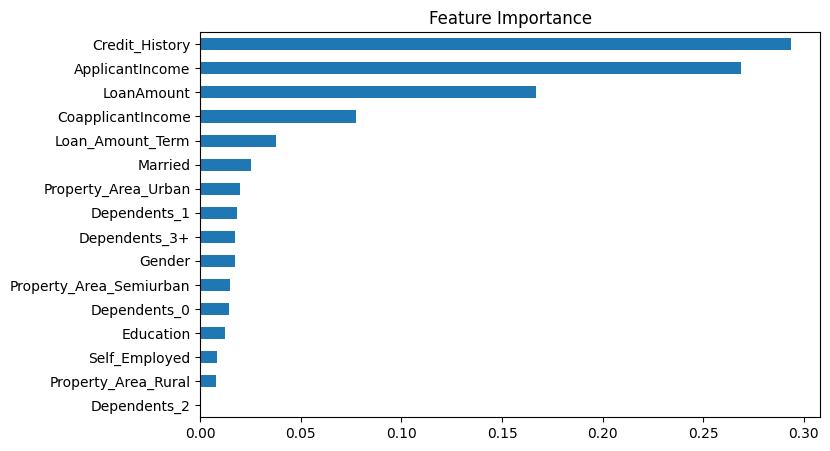

In [29]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

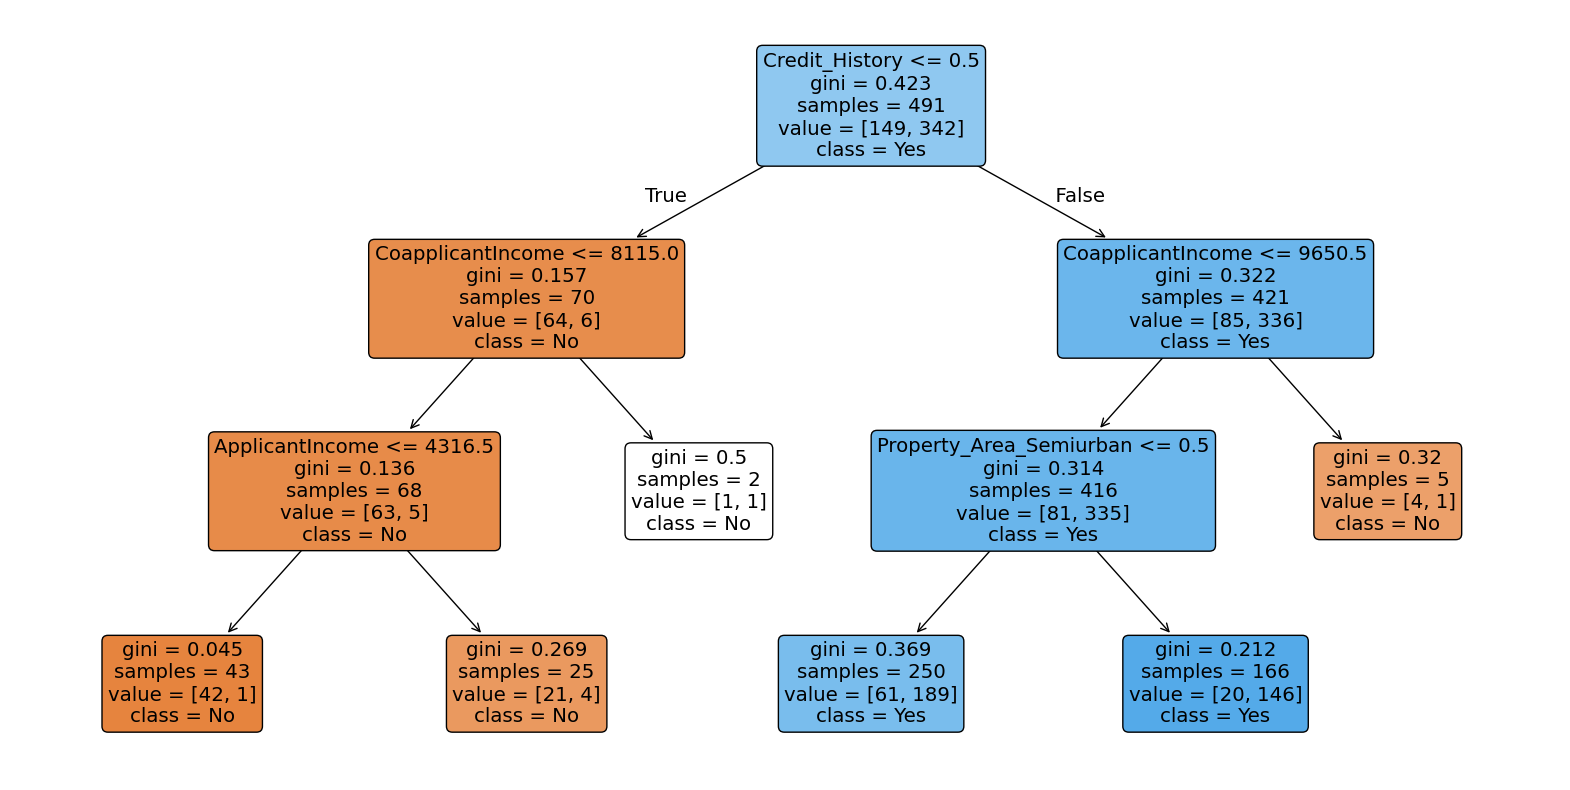

In [20]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

plt.show()

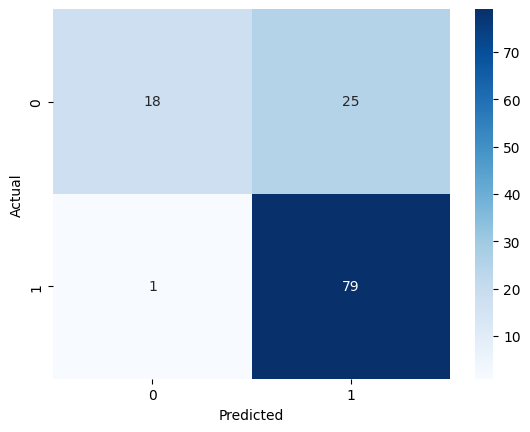

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

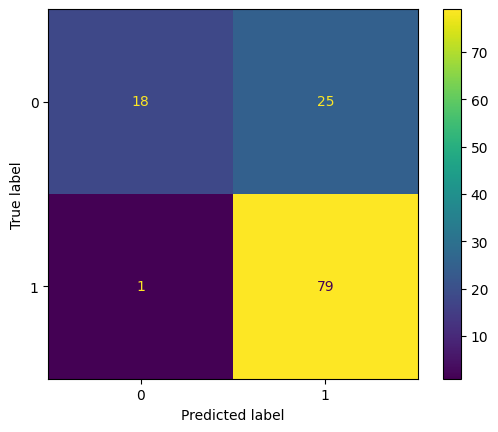

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
plt.show()

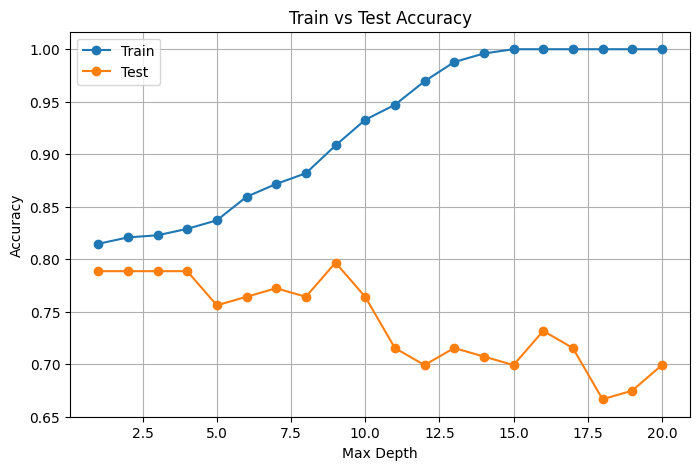

In [26]:
depths = []
train_acc = []
test_acc = []

for d in range(1,21):

    model = DecisionTreeClassifier(max_depth=d)

    model.fit(X_train,y_train)

    depths.append(d)

    train_acc.append(model.score(X_train,y_train))

    test_acc.append(model.score(X_test,y_test))

plt.figure(figsize=(8,5))

plt.plot(depths,train_acc,label="Train",marker="o")
plt.plot(depths,test_acc,label="Test",marker="o")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")

plt.legend()

plt.grid()

plt.show()